# Franco Dataset — Exploratory Data Analysis (EDA)
## Phase 1: Data Collection Analysis
**Dataset:** Egyptian Franco Arabic collected from YouTube, Reddit, and WhatsApp  
**Goal:** Understand the data before building the ML model

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# Arabic text support
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
plt.style.use('seaborn-v0_8-whitegrid')

print("✓ All libraries loaded successfully")

✓ All libraries loaded successfully


In [4]:
# Load all three datasets
youtube = pd.read_csv('../data/raw/youtube_comments.csv')
reddit = pd.read_csv('../data/raw/reddit_comments.csv')
whatsapp = pd.read_csv('../data/raw/whatsapp_messages.csv')

# Combine all sources
df = pd.concat([youtube, reddit, whatsapp], ignore_index=True)

print(f"YouTube:  {len(youtube):,} messages")
print(f"Reddit:   {len(reddit):,} messages")
print(f"WhatsApp: {len(whatsapp):,} messages")
print(f"─────────────────────")
print(f"Total:    {len(df):,} messages")

YouTube:  2,273 messages
Reddit:   137 messages
WhatsApp: 15,715 messages
─────────────────────
Total:    18,125 messages


In [5]:
# Basic dataset info
print("=== DATASET OVERVIEW ===\n")
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nDuplicated rows: {df.duplicated(subset='franco').sum():,}")

=== DATASET OVERVIEW ===

Shape: (18125, 7)

Columns: ['franco', 'arabic', 'english', 'source', 'annotator', 'verified', 'collected_at']

Data Types:
franco              str
arabic          float64
english         float64
source              str
annotator       float64
verified           bool
collected_at        str
dtype: object

Missing Values:
franco              0
arabic          18125
english         18125
source              0
annotator       18125
verified            0
collected_at        0
dtype: int64

Duplicated rows: 462


In [6]:
# Remove duplicates
df_clean = df.drop_duplicates(subset='franco').copy()

# Remove very short messages (less than 3 words)
df_clean['word_count'] = df_clean['franco'].str.split().str.len()
df_clean = df_clean[df_clean['word_count'] >= 3]

# Remove very long messages (more than 50 words - likely not Franco)
df_clean = df_clean[df_clean['word_count'] <= 50]

# Reset index
df_clean = df_clean.reset_index(drop=True)

print("=== AFTER CLEANING ===\n")
print(f"Original:   {len(df):,} messages")
print(f"Duplicates removed: {df.duplicated(subset='franco').sum():,}")
print(f"Too short removed:  {len(df) - len(df_clean) - df.duplicated(subset='franco').sum():,}")
print(f"─────────────────────")
print(f"Clean dataset: {len(df_clean):,} messages")
print(f"\nSource distribution:")
print(df_clean['source'].str.split('_').str[0].value_counts())

=== AFTER CLEANING ===

Original:   18,125 messages
Duplicates removed: 462
Too short removed:  2,417
─────────────────────
Clean dataset: 15,246 messages

Source distribution:
source
whatsapp    13267
youtube      1905
reddit         74
Name: count, dtype: int64


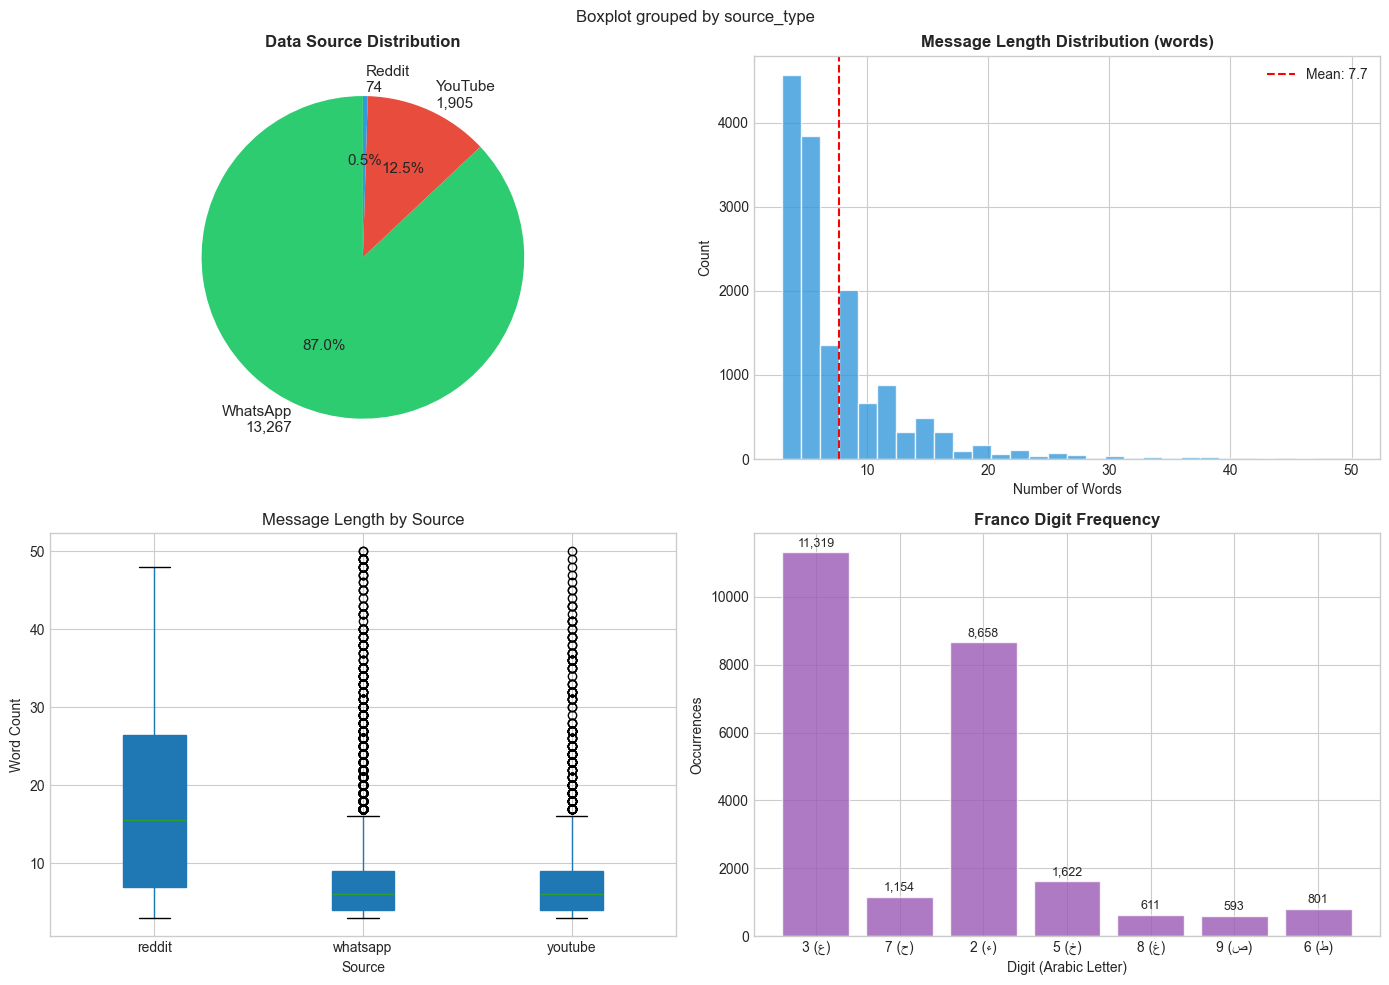

✓ Plot saved to notebooks/eda_overview.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Franco Dataset — EDA Overview', fontsize=16, fontweight='bold', y=1.02)

# Plot 1: Source Distribution
source_labels = ['WhatsApp\n13,267', 'YouTube\n1,905', 'Reddit\n74']
source_sizes = [13267, 1905, 74]
colors = ['#2ecc71', '#e74c3c', '#3498db']
axes[0,0].pie(source_sizes, labels=source_labels, colors=colors,
              autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
axes[0,0].set_title('Data Source Distribution', fontweight='bold')

# Plot 2: Message Length Distribution
axes[0,1].hist(df_clean['word_count'], bins=30, color='#3498db', 
               edgecolor='white', alpha=0.8)
axes[0,1].set_title('Message Length Distribution (words)', fontweight='bold')
axes[0,1].set_xlabel('Number of Words')
axes[0,1].set_ylabel('Count')
axes[0,1].axvline(df_clean['word_count'].mean(), color='red', 
                   linestyle='--', label=f"Mean: {df_clean['word_count'].mean():.1f}")
axes[0,1].legend()

# Plot 3: Word count by source
source_col = df_clean['source'].str.split('_').str[0]
df_clean['source_type'] = source_col
df_clean.boxplot(column='word_count', by='source_type', ax=axes[1,0],
                 patch_artist=True)
axes[1,0].set_title('Message Length by Source', fontweight='bold')
axes[1,0].set_xlabel('Source')
axes[1,0].set_ylabel('Word Count')
plt.sca(axes[1,0])
plt.title('Message Length by Source')

# Plot 4: Franco digits frequency
franco_digits = {'3 (ع)': 0, '7 (ح)': 0, '2 (ء)': 0, 
                 '5 (خ)': 0, '8 (غ)': 0, '9 (ص)': 0, '6 (ط)': 0}

for text in df_clean['franco'].str.lower():
    for digit, letter in [('3','3 (ع)'), ('7','7 (ح)'), ('2','2 (ء)'),
                           ('5','5 (خ)'), ('8','8 (غ)'), ('9','9 (ص)'), ('6','6 (ط)')]:
        franco_digits[letter] += text.count(digit)

digits = list(franco_digits.keys())
counts = list(franco_digits.values())
bars = axes[1,1].bar(digits, counts, color='#9b59b6', edgecolor='white', alpha=0.8)
axes[1,1].set_title('Franco Digit Frequency', fontweight='bold')
axes[1,1].set_xlabel('Digit (Arabic Letter)')
axes[1,1].set_ylabel('Occurrences')
for bar, count in zip(bars, counts):
    axes[1,1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
                   f'{count:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../notebooks/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved to notebooks/eda_overview.png")

Calculating Franco ratio for all messages...

=== FRANCO RATIO DISTRIBUTION ===

count    15246.000
mean         0.810
std          0.283
min          0.000
25%          0.750
50%          1.000
75%          1.000
max          1.000
Name: franco_ratio, dtype: float64

=== EXAMPLES BY FRANCO RATIO ===

High Franco (ratio > 0.7):
  → 3=ع
4=ق
5=خ

6=ط
8=غ
9=ص
  → 3=ع
4=ق
5=خ

6=ط
8=غ
9=ص
Brb
  → 2nt bwaztly ello8a m4 3almtny 
Mal7oza (b3raf 2tklm mn zaman 2sla

Medium Franco (ratio 0.3-0.7):
  → 3 ع
4 ق
5 خ
6 ط
7 ح 
8 غ
9 ص
  → 3=ع
4=ق
4=خ
6=ط
8=غ
9=ص
  → 9 ض
9 ص
؟؟

Low Franco (ratio < 0.3):
  → مين هون بي2026 🎉
  → 3. =. ع
4. =. ق
5. =. خ
6. =. ط
7. =. ح
8. =. غ
9. =. ص
  → مفروض 2 ق و 4 ش


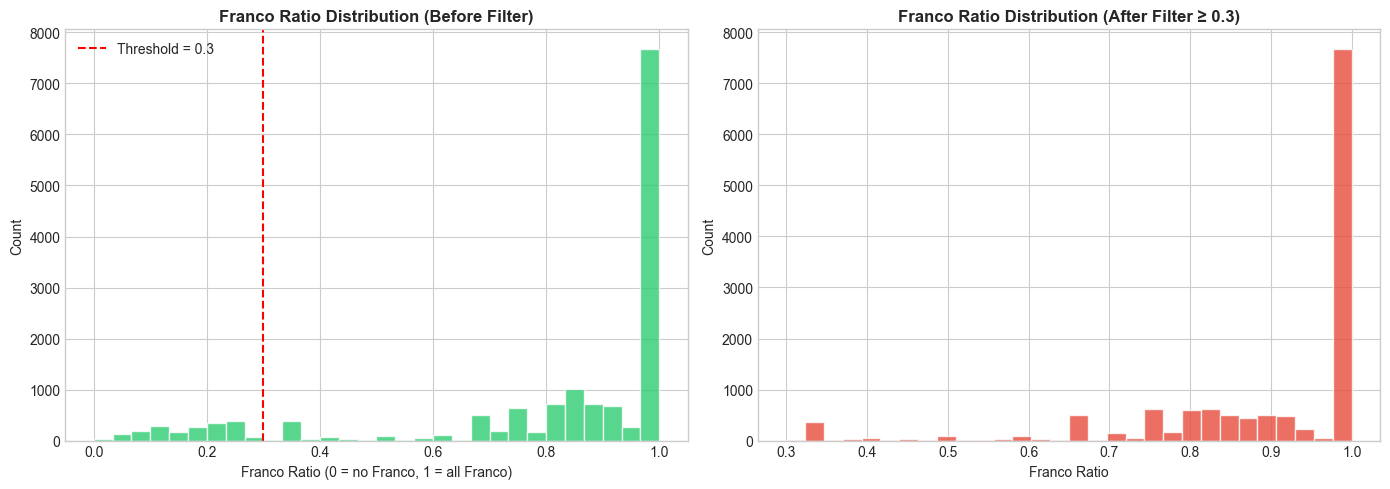


=== FILTERING RESULTS ===
Before filter: 15,246 messages
After filter:  13,373 messages
Removed:       1,873 low-quality messages

Source distribution after filter:
source_type
whatsapp    12608
youtube       735
reddit         30
Name: count, dtype: int64


In [8]:
def franco_ratio(text: str) -> float:
    """
    Calculate the ratio of Franco content in a message.
    Returns a score between 0 and 1.
    """
    text_lower = text.lower()
    words = text_lower.split()
    if not words:
        return 0.0
    
    franco_digits = ['3', '7', '2', '5', '8', '9', '6']
    franco_keywords = [
        "mesh", "msh", "ana", "enta", "howa", "hya",
        "delwa2ty", "bukra", "ba3den", "3shan", "sa7",
        "sa7bi", "ya3ni", "bas", "5alas", "7aga", "3amel",
        "tab3an", "wala", "leh", "ezay", "fein", "emta",
        "keda", "kida", "dah", "deh", "yasta", "ya3",
        "mabsout", "3yzak", "3ayzak", "7elw", "kwayes",
        "bta3", "zay", "leeh", "mn", "3la", "fe", "bs",
        "tayeb", "yani", "mafish", "wallahi", "bgd",
    ]
    
    franco_word_count = 0
    for word in words:
        # Word contains Franco digit
        has_digit = any(d in word for d in franco_digits)
        # Word is a known Franco keyword
        is_keyword = word in franco_keywords
        # Word is Latin letters (romanized Arabic)
        is_latin = bool(re.match(r'^[a-z]+$', word)) and len(word) >= 2
        
        if has_digit or is_keyword or is_latin:
            franco_word_count += 1
    
    return franco_word_count / len(words)


# Calculate Franco ratio for all messages
print("Calculating Franco ratio for all messages...")
df_clean['franco_ratio'] = df_clean['franco'].apply(franco_ratio)

# Show distribution
print("\n=== FRANCO RATIO DISTRIBUTION ===\n")
print(df_clean['franco_ratio'].describe().round(3))

# Plot distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['franco_ratio'], bins=30, 
             color='#2ecc71', edgecolor='white', alpha=0.8)
axes[0].set_title('Franco Ratio Distribution (Before Filter)', fontweight='bold')
axes[0].set_xlabel('Franco Ratio (0 = no Franco, 1 = all Franco)')
axes[0].set_ylabel('Count')
axes[0].axvline(0.3, color='red', linestyle='--', label='Threshold = 0.3')
axes[0].legend()

# Show examples at different ratios
print("\n=== EXAMPLES BY FRANCO RATIO ===\n")
print("High Franco (ratio > 0.7):")
high = df_clean[df_clean['franco_ratio'] > 0.7]['franco'].head(3).tolist()
for ex in high:
    print(f"  → {ex[:80]}")

print("\nMedium Franco (ratio 0.3-0.7):")
mid = df_clean[(df_clean['franco_ratio'] >= 0.3) & 
               (df_clean['franco_ratio'] < 0.7)]['franco'].head(3).tolist()
for ex in mid:
    print(f"  → {ex[:80]}")

print("\nLow Franco (ratio < 0.3):")
low = df_clean[df_clean['franco_ratio'] < 0.3]['franco'].head(3).tolist()
for ex in low:
    print(f"  → {ex[:80]}")

# Apply filter
df_filtered = df_clean[df_clean['franco_ratio'] >= 0.3].copy()
df_filtered = df_filtered.reset_index(drop=True)

axes[1].hist(df_filtered['franco_ratio'], bins=30,
             color='#e74c3c', edgecolor='white', alpha=0.8)
axes[1].set_title('Franco Ratio Distribution (After Filter ≥ 0.3)', fontweight='bold')
axes[1].set_xlabel('Franco Ratio')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../notebooks/franco_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n=== FILTERING RESULTS ===")
print(f"Before filter: {len(df_clean):,} messages")
print(f"After filter:  {len(df_filtered):,} messages")
print(f"Removed:       {len(df_clean) - len(df_filtered):,} low-quality messages")
print(f"\nSource distribution after filter:")
print(df_filtered['source_type'].value_counts())

In [9]:
# Select final columns for processed dataset
df_processed = df_filtered[[
    'franco', 'arabic', 'english', 
    'source', 'source_type', 'franco_ratio',
    'word_count', 'verified', 'collected_at'
]].copy()

# Save to processed folder
df_processed.to_csv('../data/processed/franco_dataset_v1.csv', 
                    index=False, encoding='utf-8-sig')

print("=== FINAL DATASET SUMMARY ===\n")
print(f"Total messages:     {len(df_processed):,}")
print(f"Avg Franco ratio:   {df_processed['franco_ratio'].mean():.2%}")
print(f"Avg message length: {df_processed['word_count'].mean():.1f} words")
print(f"\nSource breakdown:")
for source, count in df_processed['source_type'].value_counts().items():
    pct = count/len(df_processed)*100
    print(f"  {source:<12} → {count:,} ({pct:.1f}%)")

print(f"\nAnnotation status:")
print(f"  Need annotation: {(df_processed['arabic'].isna()).sum():,} messages")
print(f"  Annotated:       {(df_processed['arabic'].notna()).sum():,} messages")

print(f"\n✓ Saved to data/processed/franco_dataset_v1.csv")

# Final sample
print("\n=== SAMPLE OF CLEAN FRANCO DATA ===\n")
sample = df_processed[df_processed['franco_ratio'] > 0.8]['franco'].sample(10, random_state=42)
for i, text in enumerate(sample, 1):
    print(f"{i:2}. {text[:70]}")

=== FINAL DATASET SUMMARY ===

Total messages:     13,373
Avg Franco ratio:   89.99%
Avg message length: 7.3 words

Source breakdown:
  whatsapp     → 12,608 (94.3%)
  youtube      → 735 (5.5%)
  reddit       → 30 (0.2%)

Annotation status:
  Need annotation: 13,373 messages
  Annotated:       0 messages

✓ Saved to data/processed/franco_dataset_v1.csv

=== SAMPLE OF CLEAN FRANCO DATA ===

 1. Ashan keda ehna bnt2aked mnak bas
 2. Rabe3 haga tts
 3. Ana gai fe spoilers
 4. w 3arf bs de tafha hwa ana asmy ghalt
 5. Ana msh fahem
 6. Enta btet3eb nafsak leh
 7. Sa7eb kalemat oghnyt baby shark
 8. Khlas kda el sa3a 2:30 khlas
 9. Kolo bysme al chatbots keda
10. Fel genana beta3t tito


## EDA Summary & Key Findings

### Dataset Stats
| Metric | Value |
|--------|-------|
| Total messages | 13,373 |
| Avg Franco ratio | 89.99% |
| Avg message length | 7.3 words |
| Sources | 3 (WhatsApp, YouTube, Reddit) |

### Key Findings

1. **WhatsApp is the dominant source (94.3%)** — Real conversational Franco,
   highest quality for training.

2. **Franco digit usage** — The digit `3` (ع) is the most common (11,319 times),
   followed by `2` (ء) with 8,658 occurrences.

3. **Message length** — Right-skewed distribution, most messages are 3-10 words.
   Ideal for sequence-to-sequence models.

4. **High Franco purity** — After filtering, avg Franco ratio is 90%.
   The model will learn from clean, natural Franco.

5. **Annotation needed** — All 13,373 messages need Arabic + English translation.
   This is Phase 2 of the project.

### Next Steps
- [ ] Manual annotation of 500 seed examples (high priority)
- [ ] Auto-annotation using existing Arabic NLP tools
- [ ] Train baseline Seq2Seq model
- [ ] Evaluate with BLEU score

In [10]:
print("=" * 50)
print("EDA COMPLETE ✓")
print("=" * 50)
print(f"\nClean dataset saved to:")
print(f"  data/processed/franco_dataset_v1.csv")
print(f"\nPlots saved to:")
print(f"  notebooks/eda_overview.png")
print(f"  notebooks/franco_ratio.png")
print(f"\nReady for Phase 2: Model Training 🚀")

EDA COMPLETE ✓

Clean dataset saved to:
  data/processed/franco_dataset_v1.csv

Plots saved to:
  notebooks/eda_overview.png
  notebooks/franco_ratio.png

Ready for Phase 2: Model Training 🚀
